<a href="https://colab.research.google.com/github/davidogm/RNAP/blob/main/RNN_DNA_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN for DNA Sequence Classification 🧬

## Task
Given a DNA sequence, predict whether it contains the motif **'ATG'**.

We will:
1. Generate synthetic DNA sequences
2. Encode them using one-hot encoding
3. Train a SimpleRNN classifier
4. Evaluate performance


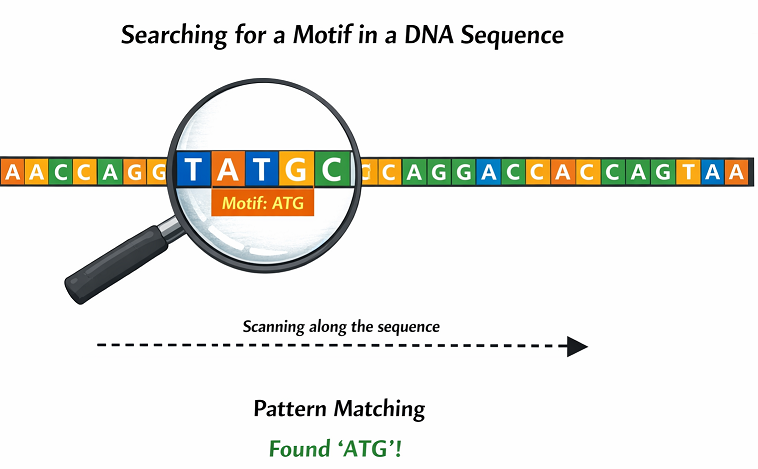

**¿Por qué usamos “ATG”?**

Porque en biología molecular: ATG

es el codón de inicio (start codon) en el DNA.

El DNA se lee en grupos de 3 nucleótidos llamados codones.

Ejemplo:   ATG CGA TTT ...

Cada triplete codifica un aminoácido.

**¿Qué tiene de especial ATG?**

En la mayoría de los organismos:

* ATG codifica el aminoácido metionina

* Es el codón que inicia la traducción

* Señala el comienzo de una proteína

Es decir:

ATG marca el inicio de una región codificante.

Este ejemplo nos permite explicar **"pattern detection in sequences"**

Utilizamos ATG porque biológicamente es el codón de inicio.

En la genómica real, esto marca el comienzo de las regiones codificadoras de proteínas.

Aquí lo simplificamos como un problema de detección de motivos.

Interesante para conectar con RNN

Detectar “ATG” requiere:

* Leer A

* Luego T

* Luego G

* En orden

Eso introduce una dependencia secuencial pequeña (longitud 3).

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(0)
tf.random.set_seed(0)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## DNA Utilities and Encoding

🧬 Representación del DNA

DNA tiene 4 nucleótidos:

{
𝐴
,
𝐶
,
𝐺
,
𝑇
}


Los convertimos a números:
mapping = {'A':0, 'C':1, 'G':2, 'T':3}

Y luego usamos one-hot encoding:

Base	              One-hot

A	                  [1,0,0,0]

C	                  [0,1,0,0]

G	                  [0,0,1,0]

T	                  [0,0,0,1]


Entonces cada secuencia se convierte en un tensor:

(
𝑁
,
𝑇
,
4
)

In [ ]:
def generate_dna_sequence(T=30):
    bases = ['A','C','G','T']
    return ''.join(np.random.choice(bases, T))

def contains_ATG(seq):
    return 1 if 'ATG' in seq else 0

def encode_sequence(seq):
    mapping = {'A':0,'C':1,'G':2,'T':3}
    one_hot = np.zeros((len(seq),4))
    for i,base in enumerate(seq):
        one_hot[i, mapping[base]] = 1
    return one_hot

## Dataset Generation

Dataset sintético sencillo


In [ ]:
def make_dataset(n_samples=5000, T=30):
    X = []
    y = []
    for _ in range(n_samples):
        seq = generate_dna_sequence(T)
        X.append(encode_sequence(seq))
        y.append(contains_ATG(seq))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

T = 30
X, y = make_dataset(n_samples=5000, T=T)

print('Tensor shape:', X.shape)
print('Labels mean (class balance):', y.mean())

Tensor shape: (5000, 30, 4)
Labels mean (class balance): 0.3704


Ahora:

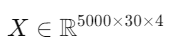

## Train / Test Split

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

(4000, 30, 4) (1000, 30, 4)


## RNN Model simple

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(T,4)),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5741 - loss: 0.6867 - val_accuracy: 0.5925 - val_loss: 0.6732
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6146 - loss: 0.6631 - val_accuracy: 0.6112 - val_loss: 0.6683
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6214 - loss: 0.6601 - val_accuracy: 0.6125 - val_loss: 0.6661
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6222 - loss: 0.6583 - val_accuracy: 0.6162 - val_loss: 0.6640
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6237 - loss: 0.6566 - val_accuracy: 0.6162 - val_loss: 0.6611


## Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6283 - loss: 0.6558
Test accuracy: 0.6420000195503235


---
##  Ejercicios

1. Reemplaza SimpleRNN por GRU y LSTM y compara la precisión.
2. Aumenta la longitud de la secuencia a T=50. ¿Cambia el rendimiento?
3. Modifica la tarea para detectar el motivo «CGT» en lugar de «ATG».
5. Detectar un patrón más largo (ej. ATG...TAA)
6. Probar el mismo modelo con secuencias más grandes